# PARTE 1: NUMPY

# 1) ¿Cuál es el tamaño en bytes de un array de 1000 elementos de tipo booleano?

In [ ]:
import numpy as np

arreglo = np.array([True] * 1000, dtype=bool)
print(arreglo.nbytes)

# Cada elemento booleano en NumPy ocupa 1 byte 

1000


# 2) Cree un array cuyos elementos sean los enteros pares en [1,100] y en orden decreciente. Muestre los 10 últimos por pantalla. 

In [2]:
import numpy as np


arreglo = np.arange(100, 0, -1)
pares = arreglo[arreglo % 2 == 0]


print(pares[-10:])

[20 18 16 14 12 10  8  6  4  2]


# 3) Dado el array  
# 2 4 5 6 
# 0 3 7 4 
# 8 8 5 2 
# 1 5 6 1 
# Seleccione con una instrucción el subarray de elementos  
# 0 3 7 4 
# Después, seleccione el subarray de elementos  
# 2 5 
# 8 5 

In [3]:
import numpy as np

A = np.array([
    [2, 4, 5, 6],
    [0, 3, 7, 4],
    [8, 8, 5, 2],
    [1, 5, 6, 1]
])

# Subarray 1
sub1 = A[1, :]
print(sub1)

# Subarray 2
sub2 = A[[0, 2]][:, [0, 2]]
print(sub2)

[0 3 7 4]
[[2 5]
 [8 5]]


# 4) Dados los arrays a = [1, 4, 2, 7] y b = [1, 3, 2, 9], obtenga la media aritmética de la diferencia (a-b). 

In [4]:
a = np.array([1, 4, 2, 7])
b = np.array([1, 3, 2, 9])

diferencia = a - b

media = np.mean(diferencia)

print(media)

-0.25


# 5) Tengo valores de cordenadas (x, y) en las columnas del array 
# 1.33 4.5 
# 30.0 10.7 
# 70.2 0.5
# Agregue a este array las coordenadas (37.1, -3.6). Muestre en pantalla las dimensiones del nuevo array. 

In [ ]:
import numpy as np

# Array original
A = np.array([
    [1.33, 4.5],
    [30.0, 10.7],
    [70.2, 0.5]
])

# Nueva coordenada
nueva_coor = np.array([[37.1, -3.6]])

# Agregar al array
nuevo_arr = np.vstack((A, nueva_coor))

print(nuevo_arr.shape)

(4, 2)


In [6]:
print(nuevo_arr)

[[ 1.33  4.5 ]
 [30.   10.7 ]
 [70.2   0.5 ]
 [37.1  -3.6 ]]


# 6) Copie el array del ejercicio anterior. Traspóngalo .Agregue ahora dos nuevos pares de coordenadas: (10.8, 3.0) y (35.8, 12.0). 

In [ ]:
import numpy as np

# Array del ejercicio anterior
A = np.array([
    [1.33, 4.5],
    [30.0, 10.7],
    [70.2, 0.5],
    [37.1, -3.6]
])

# Transponer
A_T = A.T

# Nuevas coordenadas
nuevas = np.array([
    [10.8, 35.8],
    [3.0, 12.0]
])

# Agregar columnas
A_final = np.hstack((A_T, nuevas))

print(A_final)

[[ 1.33 30.   70.2  37.1  10.8  35.8 ]
 [ 4.5  10.7   0.5  -3.6   3.   12.  ]]


# Parte 2: Exploración y Minería de datos 

In [ ]:
import pandas as pd

# Cargar archivo
df = pd.read_csv("NucleosPoblacion.csv")

# Primeras filas
print(df.head())

   FID  OBJECTID     Texto  Poblacion  CodMun Municipio  CodProvin  \
0    0         1   Agüimes    29431.0   35002   Agüimes         35   
1    1         2   Antigua    10458.0   35003   Antigua         35   
2    2         3  Arrecife    58156.0   35004  Arrecife         35   
3    3         4    Arucas    36745.0   35006    Arucas         35   
4    4         5    Gáldar    24473.0   35009    Gáldar         35   

    Provincia          X          Y  
0  Las Palmas -15.446012  27.900542  
1  Las Palmas -14.013301  28.418966  
2  Las Palmas -13.551451  28.960649  
3  Las Palmas -15.521512  28.117496  
4  Las Palmas -15.654111  28.143873  


# 1) ¿Cuántos Municipios tienen más de 100000 habitantes?.

In [ ]:
resultado = df[df["Poblacion"] > 100000]


print(resultado.shape[0])
print(resultado[["Municipio", "Poblacion"]])

62
                      Municipio  Poblacion
9    Las Palmas de Gran Canaria   383308.0
16                        Telde   100900.0
28   San Cristóbal de La Laguna   152222.0
40       Santa Cruz de Tenerife   222643.0
42                      Badajoz   150376.0
..                          ...        ...
683    Santa Coloma de Gramenet   120060.0
689                    Terrassa   212724.0
725                      Lleida   137387.0
735                        Reus   106622.0
737                   Tarragona   140184.0

[62 rows x 2 columns]


# 2) Realice una gráfica de barras sobre la polbación de cada ciudad, ordenela de menor a mayo y responda:  
# a. ¿Cuál es la segunda ciudad más poblada? 
# b. ¿Qué posición ocupa Granada en el ranking de las ciudades más pobladas? 

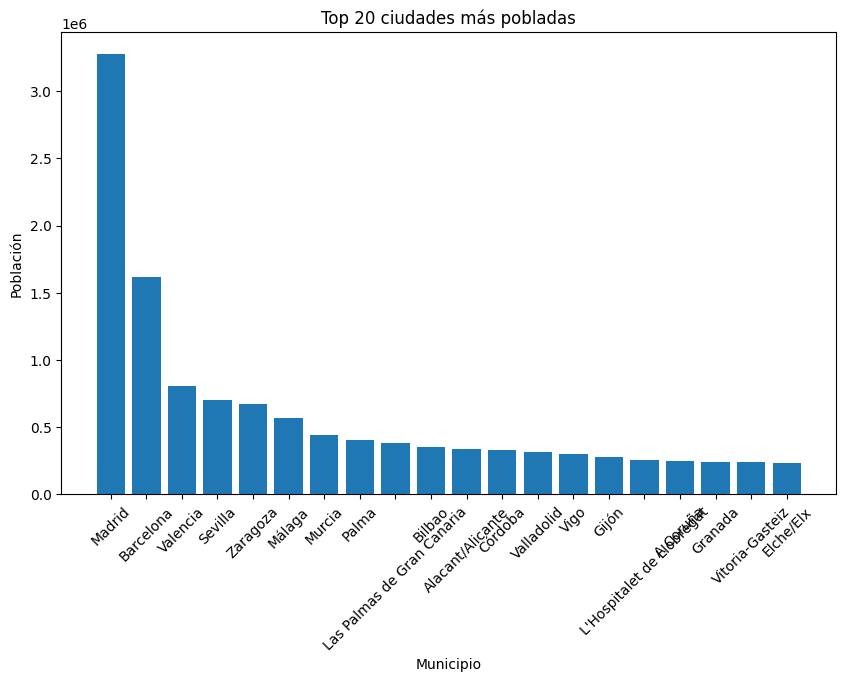

Segunda ciudad más poblada: Barcelona
Posición de Granada: 18


In [ ]:
import matplotlib.pyplot as plt
top20 = df.sort_values(by="Poblacion", ascending=False).head(20)

# Gráfica
plt.figure(figsize=(10,6))
plt.bar(top20["Municipio"], top20["Poblacion"])
plt.xticks(rotation=45)
plt.title("Top 20 ciudades más pobladas")
plt.xlabel("Municipio")
plt.ylabel("Población")
plt.show()

df_desc = df.sort_values(by="Poblacion", ascending=False).reset_index(drop=True)

# a) Segunda ciudad más poblada
segunda = df_desc.iloc[1]["Municipio"]
print("Segunda ciudad más poblada:", segunda)

# b) Posición de Granada
posicion = df_desc[df_desc["Municipio"] == "Granada"].index[0] + 1
print("Posición de Granada:", posicion)

# 3) ¿Cuántos municipios de Extremadura tienen más de 5000 habitantes?. 

In [15]:
resultado = df[(df["Provincia"].isin(["Cáceres", "Badajoz"])) & (df["Poblacion"] > 5000)]

print(resultado.shape[0])

14


# 4) ¿Cuál es el municipio situado más al Norte? (Usar el valor de la coordenada "Y" que representa la latitud en grados). Proporcione también la provincia a la que pertenece y su población.

In [16]:
norte = df.loc[df["Y"].idxmax()]

print("Municipio:", norte["Municipio"])
print("Provincia:", norte["Provincia"])
print("Población:", norte["Poblacion"])

Municipio: Viveiro
Provincia: Lugo
Población: 16211.0


# 5) Obtenga la media, mediana, desviación estándar, valor máximo y valor mínimo de la población de los municipios de la provincia de Granada.

In [17]:
granada = df[df["Provincia"] == "Granada"]

media = granada["Poblacion"].mean()
mediana = granada["Poblacion"].median()
std = granada["Poblacion"].std()
maximo = granada["Poblacion"].max()
minimo = granada["Poblacion"].min()

print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", std)
print("Máximo:", maximo)
print("Mínimo:", minimo)

Media: 30217.85
Mediana: 17526.0
Desviación estándar: 50355.49171459277
Máximo: 239154.0
Mínimo: 10386.0


# 6) Realice un histograma con la población de los Municipios para cada una de las provincias.

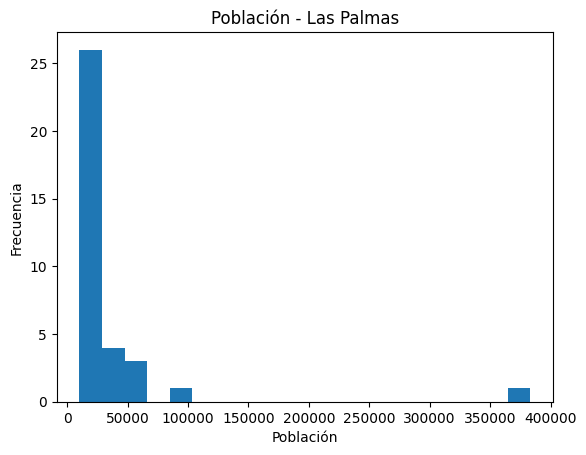

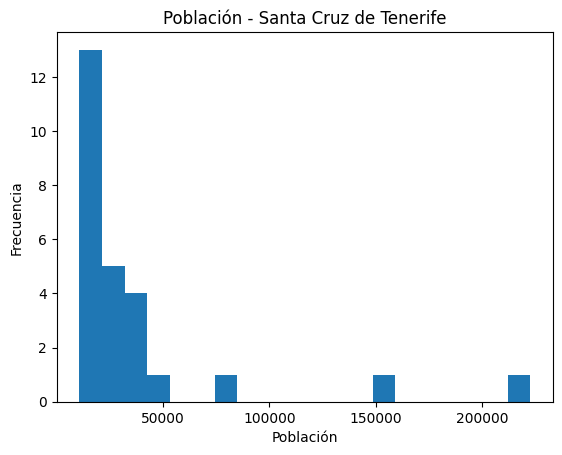

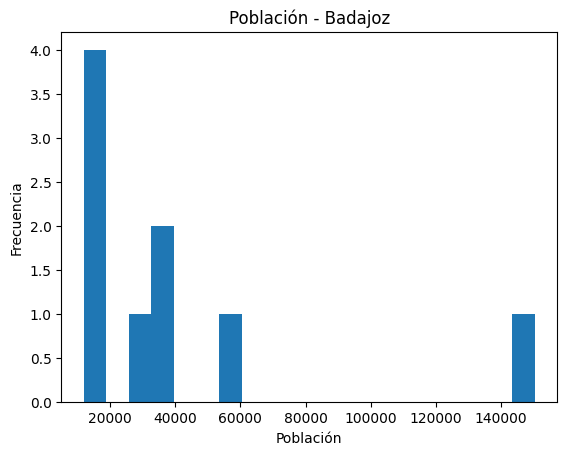

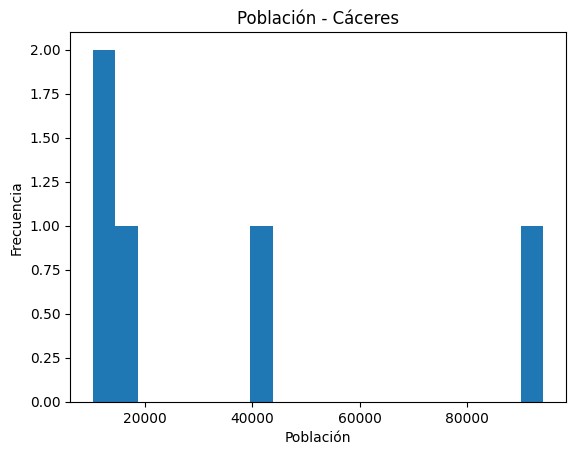

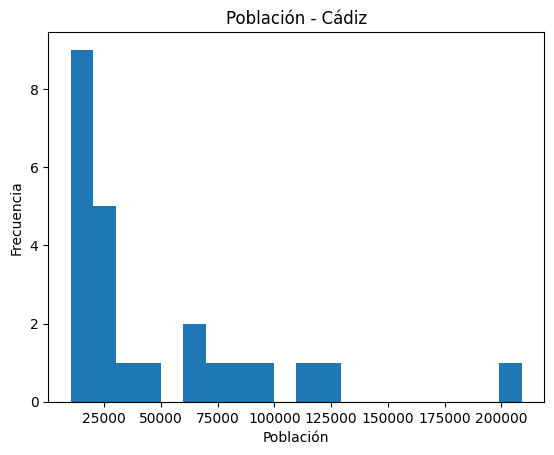

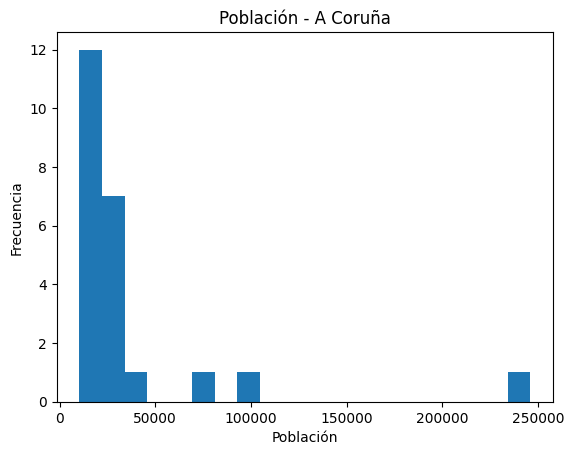

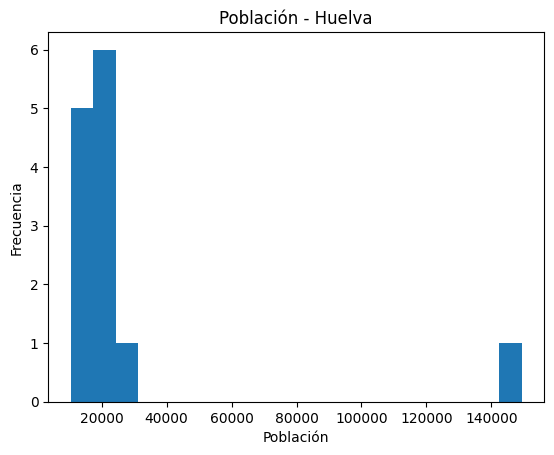

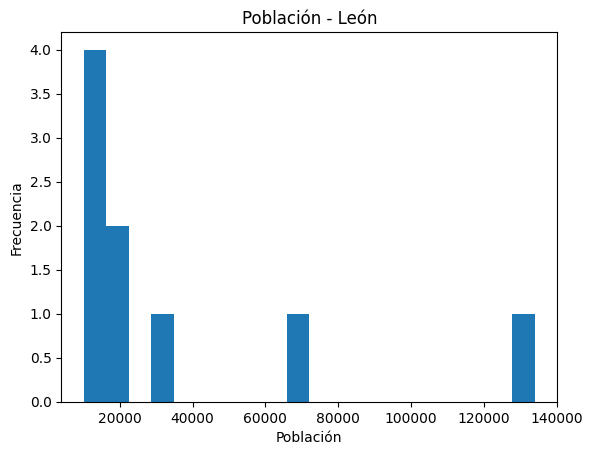

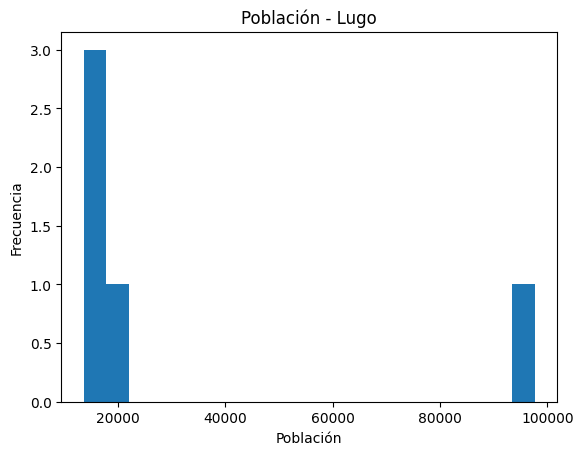

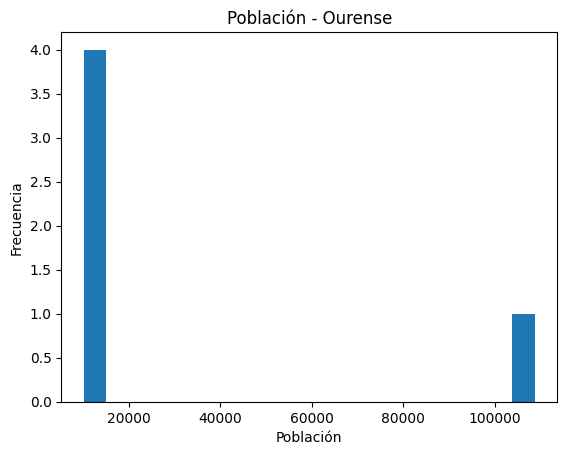

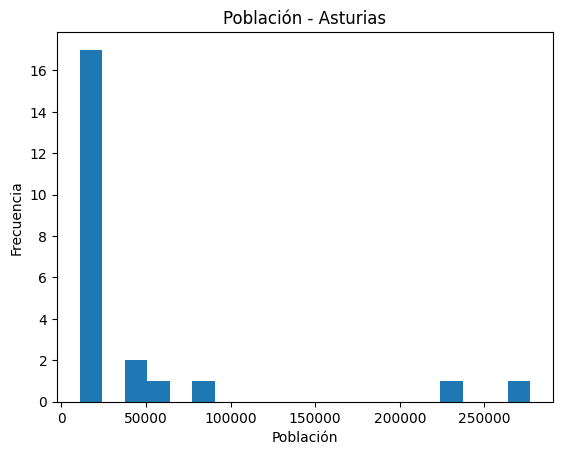

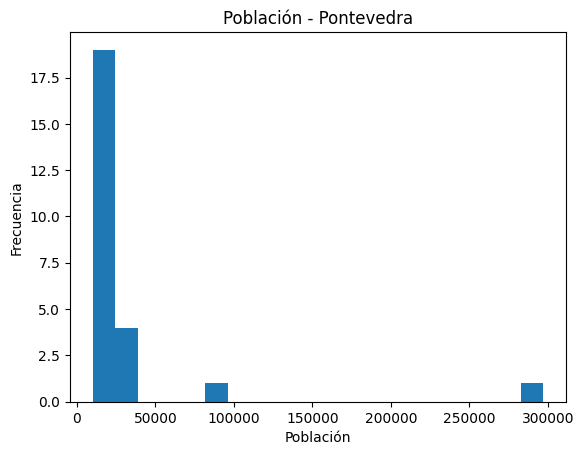

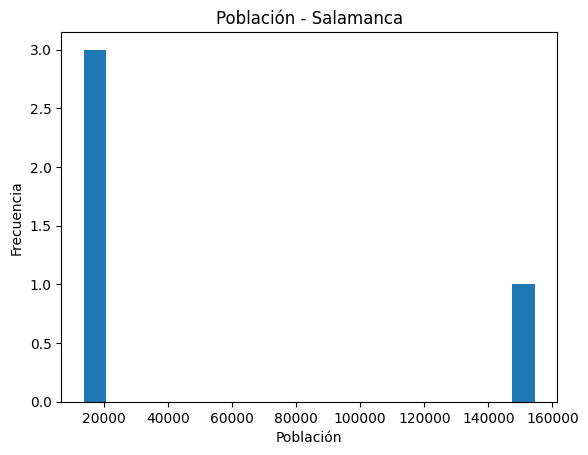

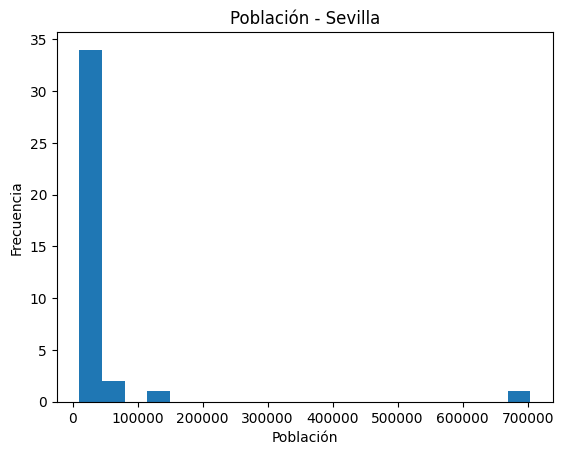

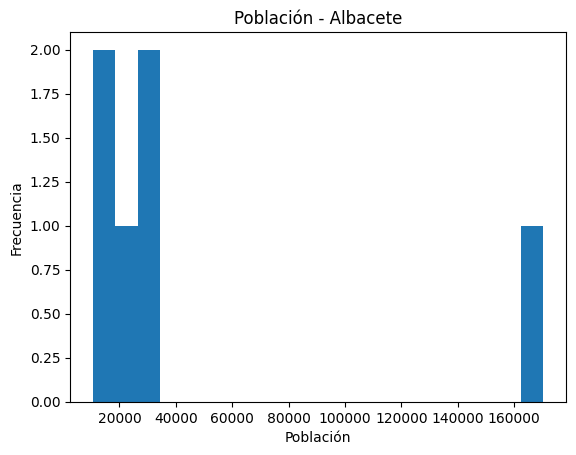

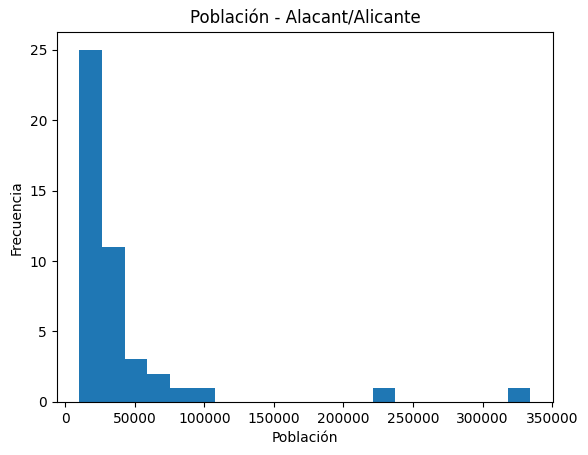

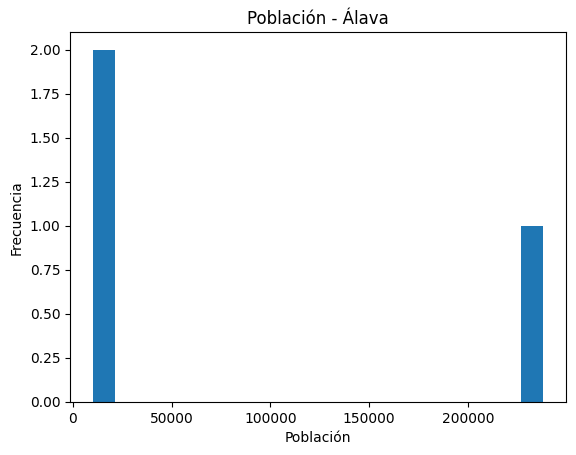

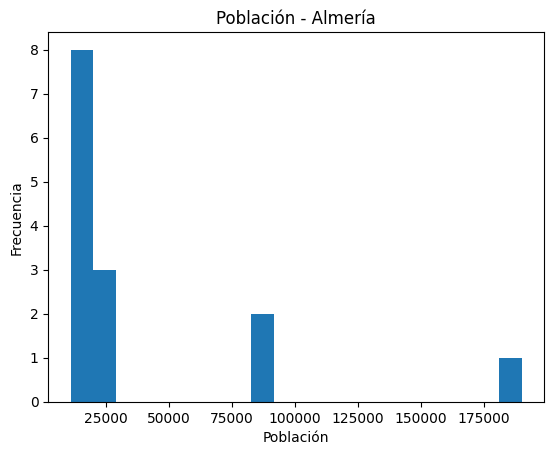

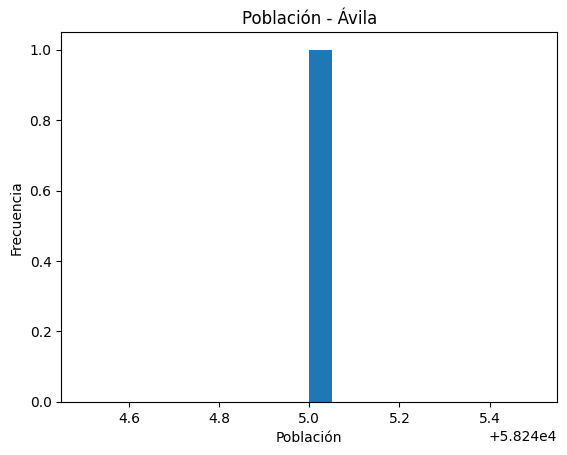

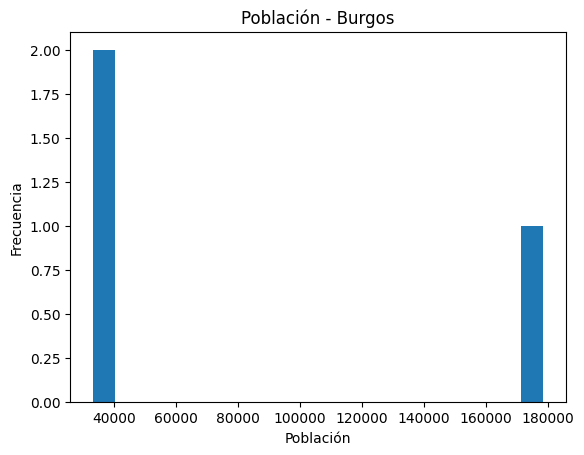

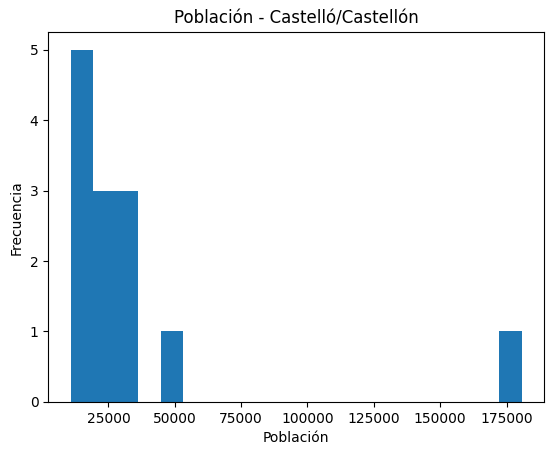

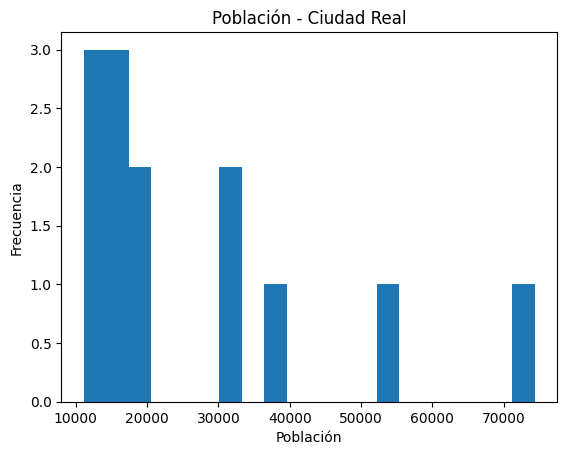

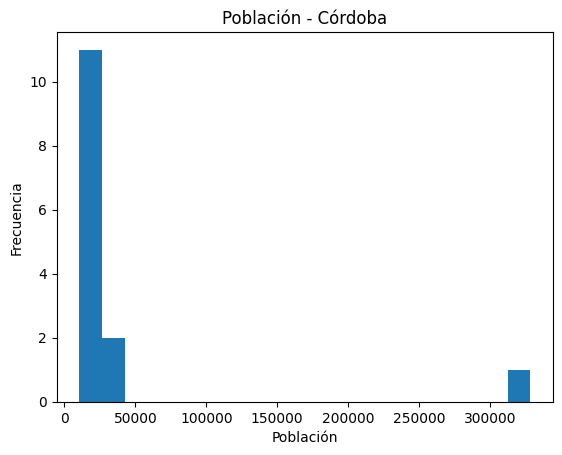

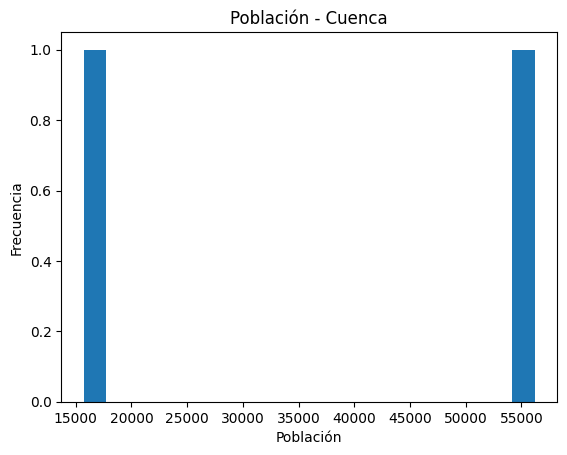

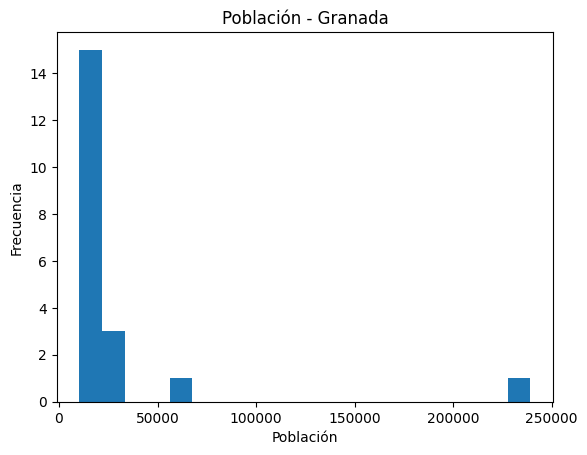

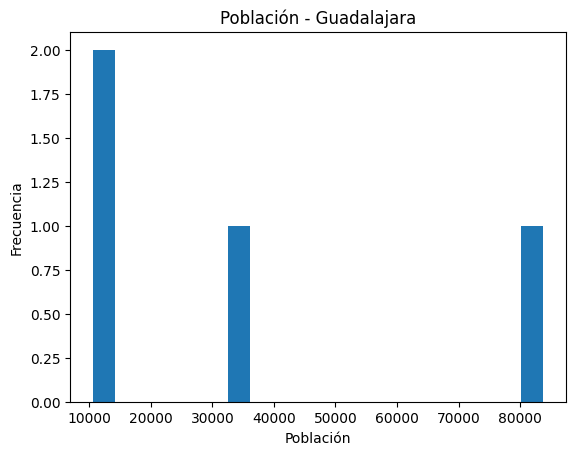

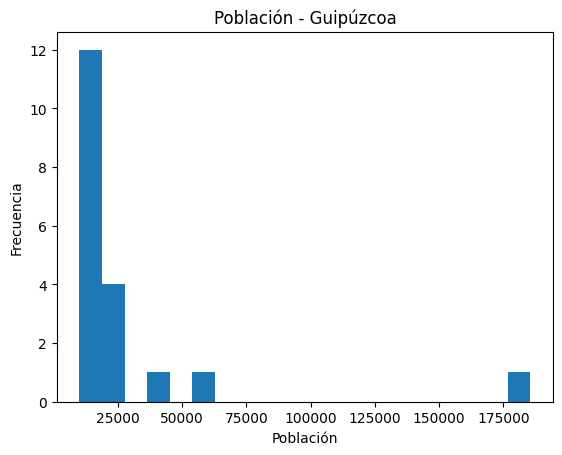

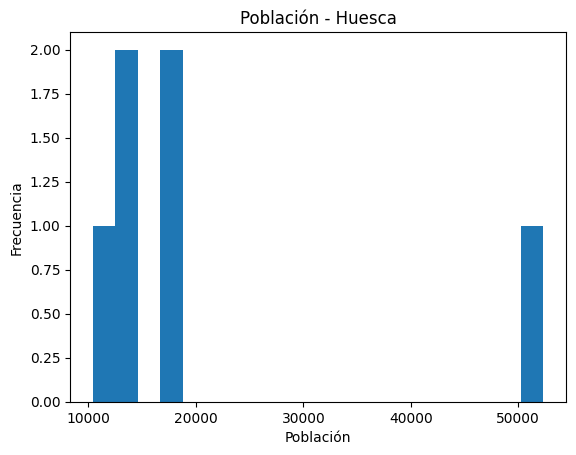

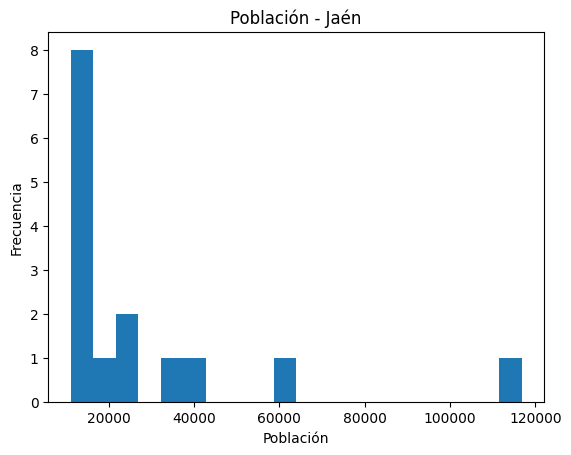

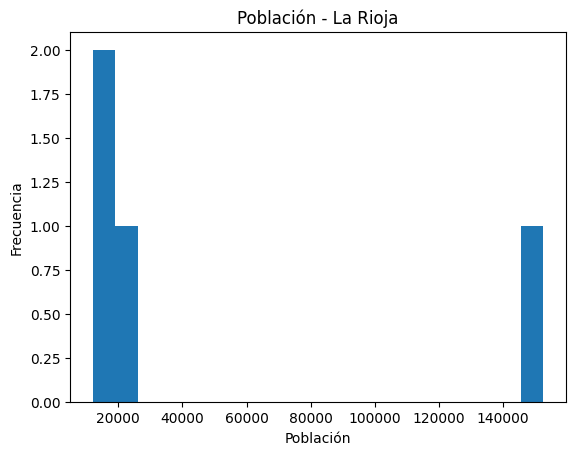

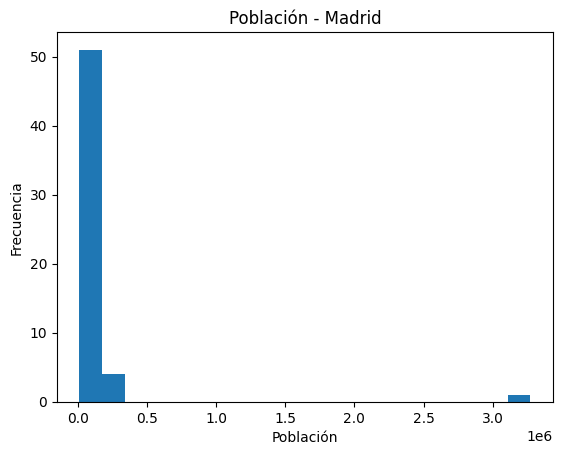

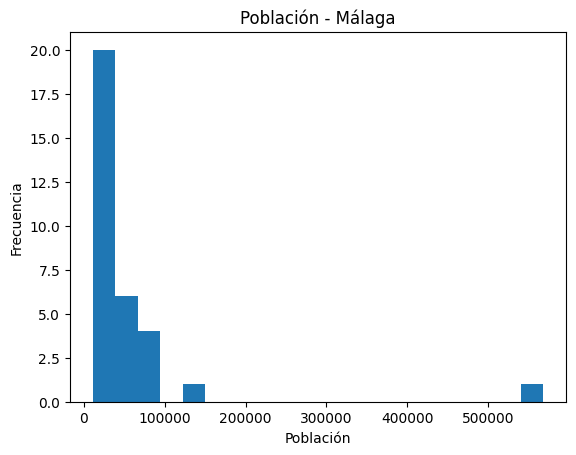

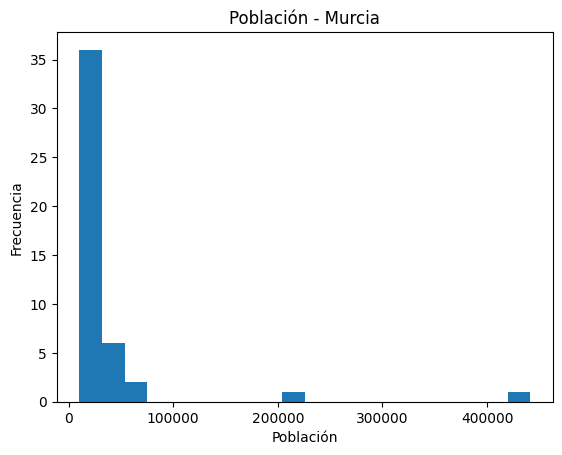

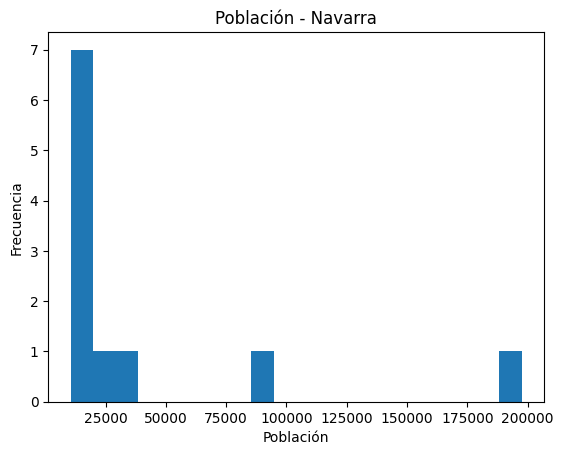

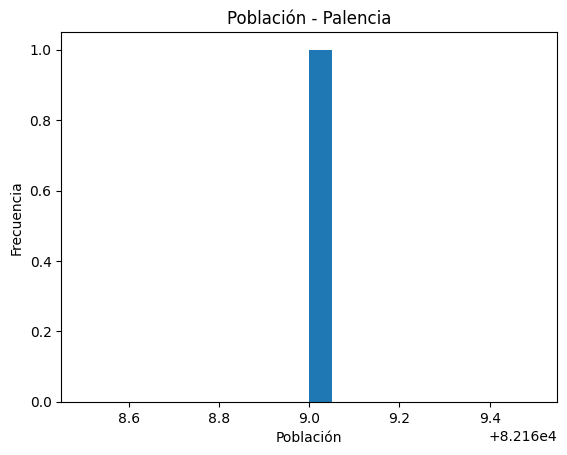

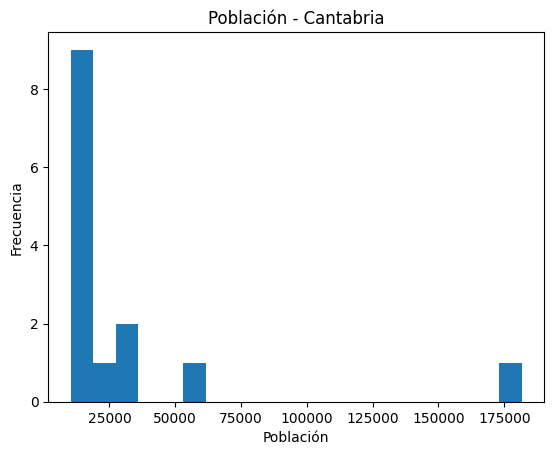

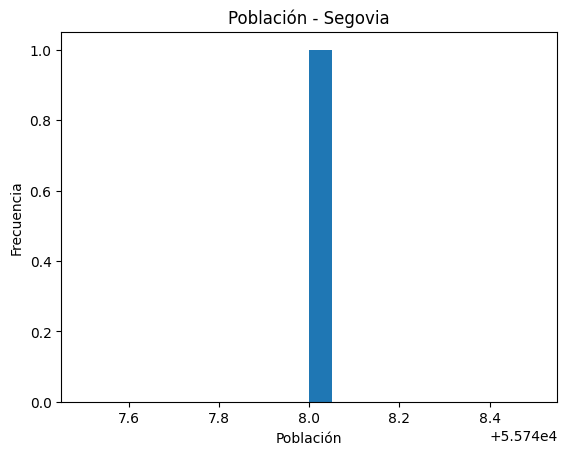

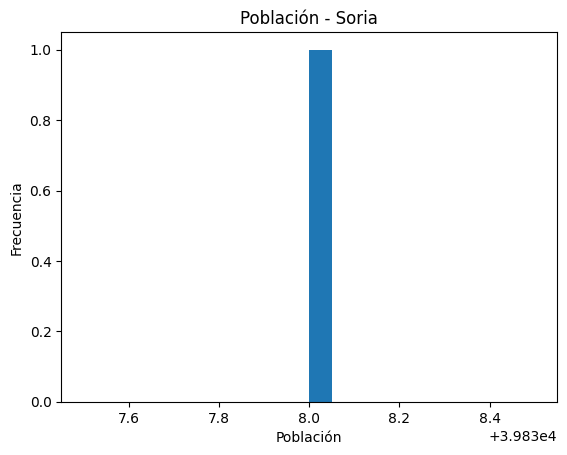

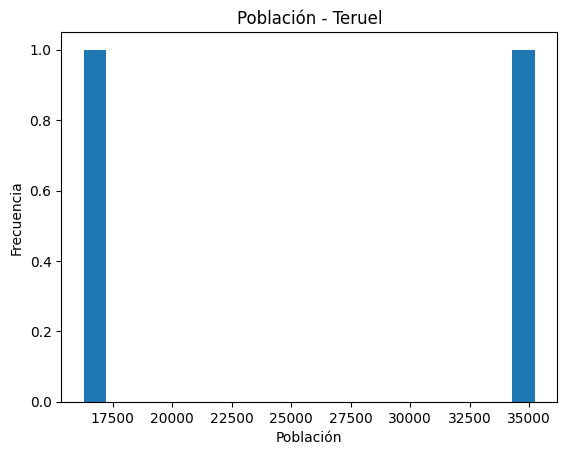

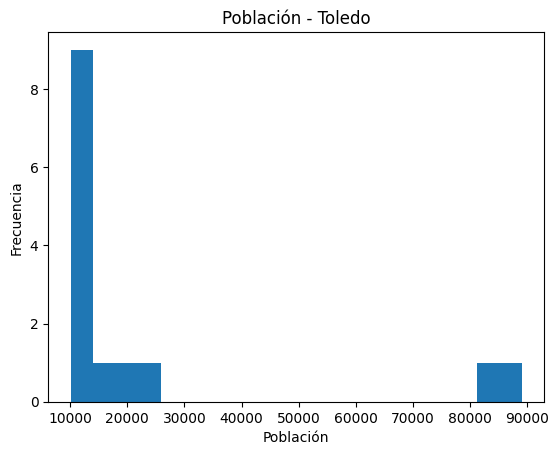

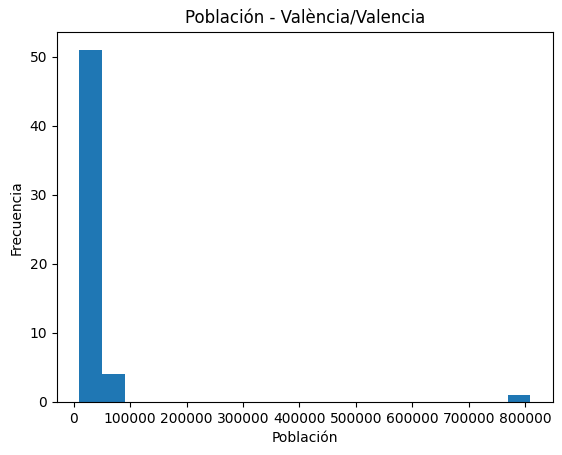

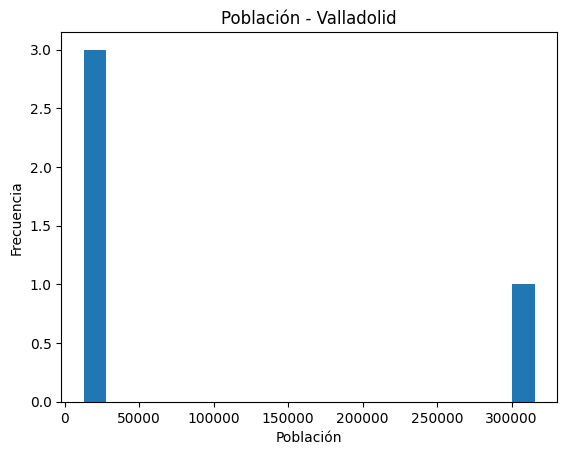

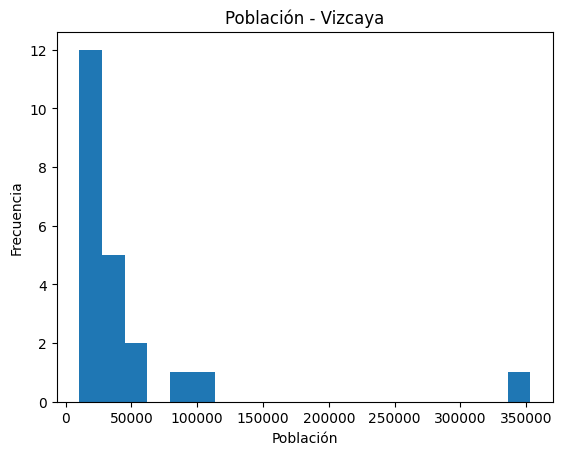

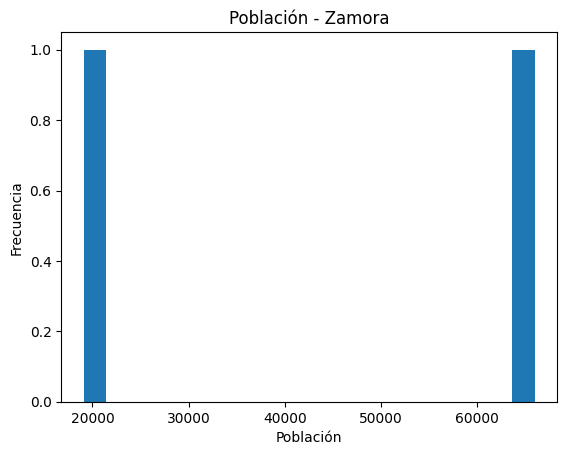

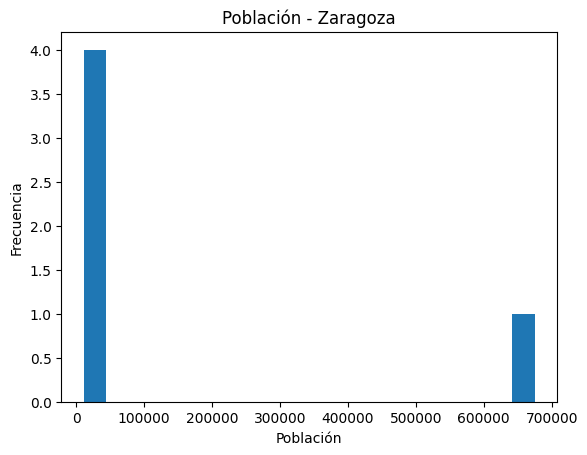

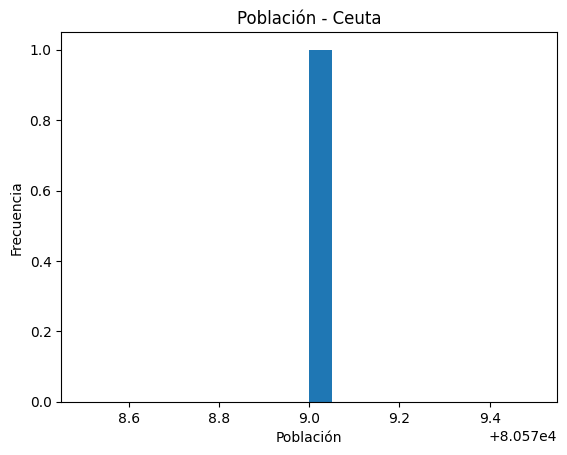

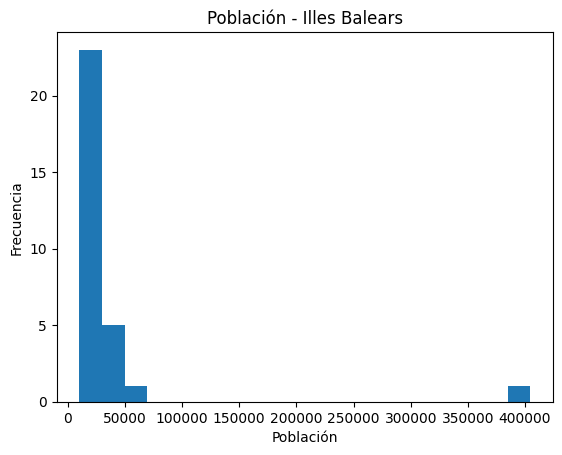

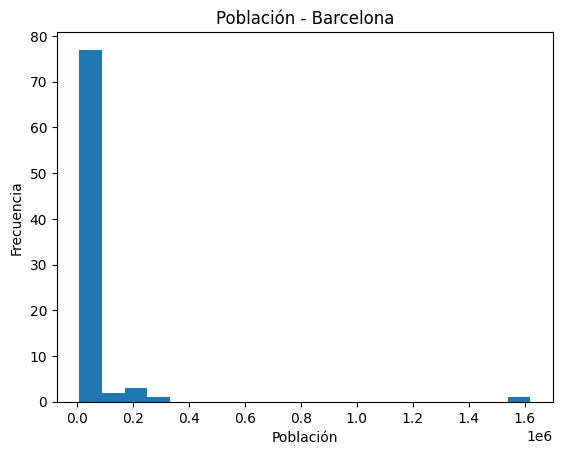

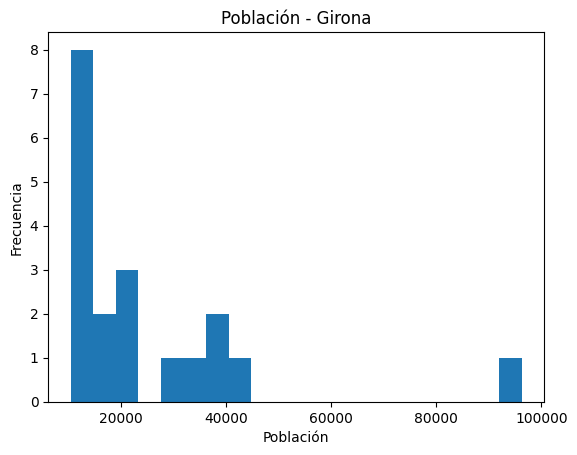

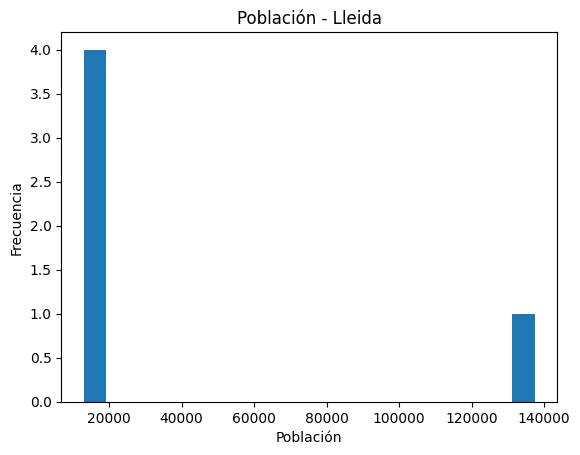

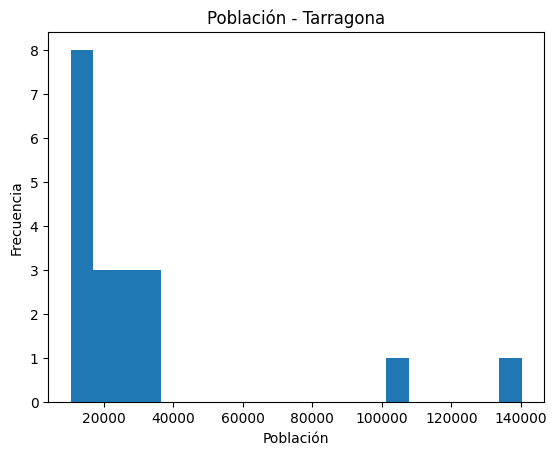

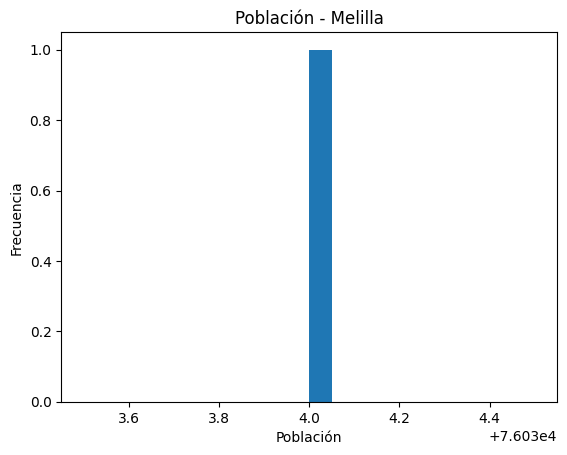

In [18]:
provincias = df["Provincia"].unique()

for provincia in provincias:
    datos = df[df["Provincia"] == provincia]["Poblacion"]
    
    plt.figure()
    plt.hist(datos, bins=20)
    plt.title(f"Población - {provincia}")
    plt.xlabel("Población")
    plt.ylabel("Frecuencia")
    plt.show()

# 7) Seleccione al azar cincuenta municipios diferentes de entre los diponibles en el archivo. Asegúrese de que no se repitan. ¿Luego calcule el promedio de la población y la desviación estándar de esto 50 municipios?. 

In [19]:
muestra = df.sample(n=50, replace=False)

promedio = muestra["Poblacion"].mean()
desviacion = muestra["Poblacion"].std()

print("Promedio:", promedio)
print("Desviación estándar:", desviacion)

Promedio: 34289.24
Desviación estándar: 46118.518934553125


# 8) Dígame los nombres de los Municipios más cercano y más lejano a Madrid. Para ello debe calcular la distancia en todos ellos y Madrid. No considere a Madrid en el análisis ya que la distancia sería cero.

In [20]:
madrid = df[df["Municipio"] == "Madrid"].iloc[0]

df2 = df[df["Municipio"] != "Madrid"]

df2["Distancia"] = np.sqrt(
    (df2["X"] - madrid["X"])**2 +
    (df2["Y"] - madrid["Y"])**2
)

print("Más cercano:", df2.loc[df2["Distancia"].idxmin(), "Municipio"])
print("Más lejano:", df2.loc[df2["Distancia"].idxmax(), "Municipio"])

Más cercano: Pozuelo de Alarcón
Más lejano: Los Llanos de Aridane
